In [1]:
import pickle as pickle
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import csv
from mpl_toolkits.axes_grid1 import host_subplot
from matplotlib import rcParams

from defs import generate_k_space_sweep, visualize_sweep, rotate_points, extract_band_structure

%load_ext autoreload
%autoreload 2

In [2]:
data_dir = '../../../data/simulation/'
out_dir = '../../../output/paper_upload/'

# Plot output toggles
SHOW_PLOT_DECORATIONS = False  # False hides labels, tick labels, legends, and titles.
SAVE_PLOT = True  # False displays figures without saving them.

In [3]:
# Load COMSOL-simulated kagome band structure data from csv file

kagome_band_data = extract_band_structure(
    data_dir + 'extkag_0_fluid_custom_mesh_allbands.csv',
    max_bands=3,
    band_selection='top',
)
frequencies_by_b_hz = kagome_band_data['frequencies_by_b_hz']
b_sim = np.asarray(list(frequencies_by_b_hz))
bands_sim = np.stack(list(frequencies_by_b_hz.values())).T / 1e3

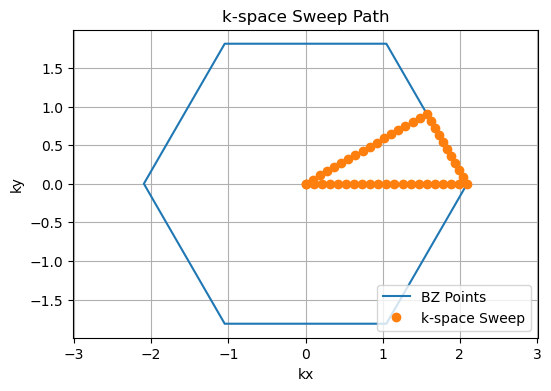

In [4]:
# Define the points in reciprocal space for the sweep
L = 1
G = np.array([0, 0])
K = np.array([2*np.pi/(3*L), 0])
M = np.array([3/2*np.pi/3/L, np.pi/np.sqrt(3)/2/L])


rcParams.update({'font.size': 10, 'axes.labelsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

b_TB, kx_TB, ky_TB = generate_k_space_sweep([G, K, M, G], num_points=len(b_sim))
BZ_points = rotate_points(K, np.linspace(0, 2*np.pi, 7, endpoint=True))
visualize_sweep((kx_TB, ky_TB), BZ_points)

In [5]:
bands_TB = np.zeros((3, len(kx_TB)))  # Placeholder for band energies
t = 1

for i, (kx, ky) in tqdm(enumerate(zip(kx_TB, ky_TB))):
    M = -t*np.array([[0, 1+np.exp(-1j*2*kx*L), 1+np.exp(-1j*(kx-np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*2*kx*L), 0, 1+np.exp(1j*(kx+np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*(kx-np.sqrt(3)*ky)*L), 1+np.exp(-1j*(kx+np.sqrt(3)*ky)*L), 0]])

    bands_TB[:,i] = np.linalg.eigvalsh(M)

0it [00:00, ?it/s]

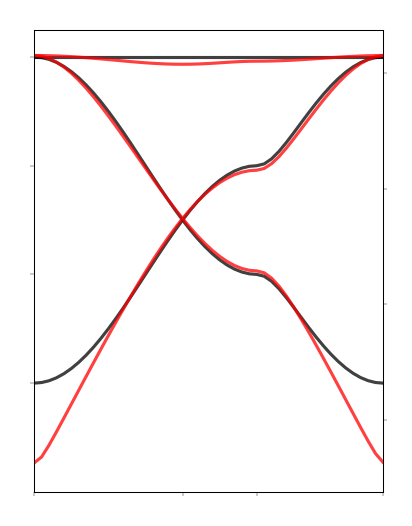

In [6]:
# Set figure size and DPI when creating the figure
rcParams.update({'font.size': 5, 'axes.labelsize': 5, 'xtick.labelsize': 5, 'ytick.labelsize': 5})
fig = plt.figure(figsize=(1.5, 2), dpi=300)
host = host_subplot(111)
par = host.twinx()

# Set axis limits
host.set_xlim(0, b_sim[-1])
host.set_ylim(-6, 2.5)
par.set_ylim(-0.5, 15.5)

# Keep the same styled axes and tick marks in both modes.
host.set_xticks([0, 1, 1.5, b_sim[-1]], ['Γ', 'K', 'M', 'Γ'])
host.set_yticks(np.linspace(-4, 2, 4, endpoint=True))
par.set_yticks(np.linspace(2, 14, 4, endpoint=True))
host.xaxis.set_tick_params(width=0.1, length=1)
host.yaxis.set_tick_params(width=0.1, length=1)
par.yaxis.set_tick_params(width=0.1, length=1)

for axis in ['top', 'bottom', 'left', 'right']:
    host.spines[axis].set_linewidth(0.25)
    par.spines[axis].set_linewidth(0.25)

if SHOW_PLOT_DECORATIONS:
    host.set_ylabel('Energy (t)')
    par.set_ylabel('Frequency (kHz)', rotation=270, labelpad=10)
else:
    host.set_xlabel('')
    host.set_ylabel('')
    par.set_ylabel('')
    host.set_title('')
    par.set_title('')
    host.tick_params(axis='x', labelbottom=False)
    host.tick_params(axis='y', labelleft=False)
    par.tick_params(axis='y', labelright=False)


# Plot the tight-binding and COMSOL-simulated band structures
for i in range(len(bands_sim)):
    host.plot(b_sim, bands_TB[i], 'k-', linewidth=0.75, alpha=0.75, label='Tight-binding' if i == 0 else None)
    par.plot(b_sim, bands_sim[i], 'r-', linewidth=0.75, alpha=0.75, label='COMSOL' if i == 0 else None)

if SHOW_PLOT_DECORATIONS:
    host.legend(loc='lower center', frameon=False)

if SAVE_PLOT:
    plt.savefig(out_dir + "kagome_fluids_bands_intro.pdf")
plt.show()